<h1> Sampling Methods

When calculating exact probabilities is difficult or impossible, we use sampling instead of an exact solution.

In many probabilistic problems:

Direct calculation of

$P(X)$

is difficult.

For example:
- The state space is very large.
- There are many variables.
- The distribution is complex.

Therefore, instead of exact calculation, we use sampling.

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

from src.sampling import (
    monte_carlo_pi,
    rejection_sampling,
    GibbsSampler
)

<h3> Step 1: Mont Carlo

 Classic example: estimating π

Consider a circle inside a square. If we generate random points within the square:
- Points inside the circle → Success
- Points outside the circle → Failure

In [12]:
monte_carlo_pi(
    10000
)

3.1336

#### Examining the Effect of the Number of Samples

Now, the most important point about Monte Carlo:
The more samples there are, the better the estimate becomes.

In [13]:
samples = [
    10,
    100,
    1000,
    10000,
    100000
]

results = [
    monte_carlo_pi(n)
    for n in samples
]

list(
    zip(
        samples,
        results
    )
)

[(10, 2.8), (100, 3.32), (1000, 3.152), (10000, 3.1628), (100000, 3.1424)]

#### Visualization — Convergence

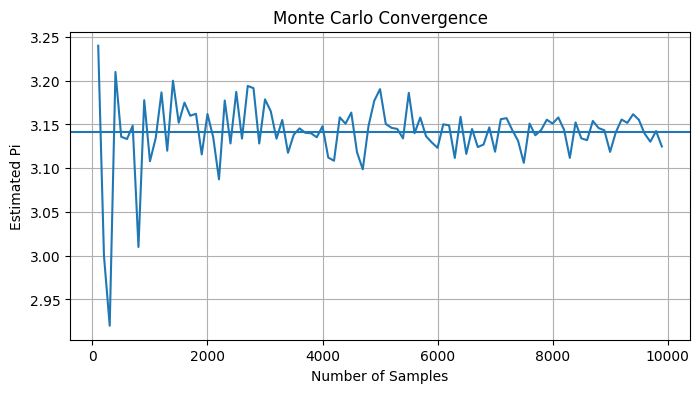

In [14]:
samples = range(
    100,
    10000,
    100
)

estimates = [
    monte_carlo_pi(n)
    for n in samples
]

plt.figure(
    figsize=(8,4)
)

plt.plot(
    samples,
    estimates
)

plt.axhline(
    3.14159
)

plt.xlabel(
    "Number of Samples"
)

plt.ylabel(
    "Estimated Pi"
)

plt.title(
    "Monte Carlo Convergence"
)

plt.grid()
plt.show()

#### The graph shows:

With few samples, there is high fluctuation.

However, as the number of samples increases, the estimated value approaches the actual value.

This is the core concept of Monte Carlo:
More samples → Better approximation

<h3> Step 2: Rejection Sampling

In [15]:
samples = rejection_sampling(
    10000
)

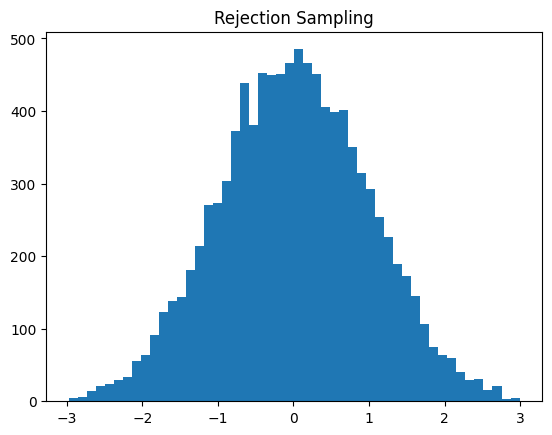

In [16]:
plt.hist(
    samples,
    bins=50
)

plt.title(
    "Rejection Sampling"
)

plt.show()

Even though we sampled from a uniform distribution, after rejecting unsuitable samples, the final distribution resembles the target distribution.

<h3> Step 3: Gibbs Sampling

In [17]:
p_a_given_b = {
    0:0.3,
    1:0.8
}

p_b_given_a = {
    0:0.2,
    1:0.7
}

In [18]:
gibbs = GibbsSampler(
    p_a_given_b,
    p_b_given_a
)

samples = gibbs.sample(
    5000
)

In [19]:
samples[:10]

[(1, 1),
 (0, 0),
 (1, 1),
 (0, 0),
 (0, 0),
 (0, 0),
 (0, 0),
 (1, 0),
 (0, 0),
 (1, 0)]

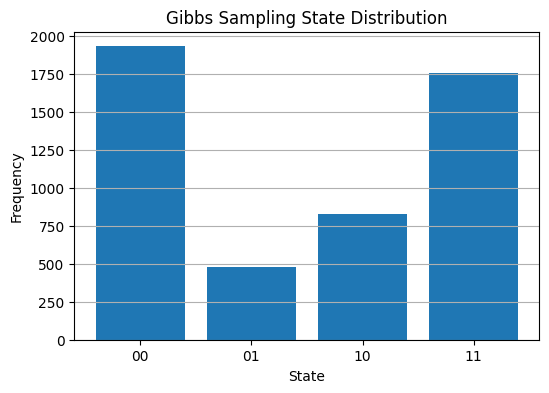

In [20]:
counts = Counter(samples)

states = [
    "00",
    "01",
    "10",
    "11"
]

values = [
    counts[(0,0)],
    counts[(0,1)],
    counts[(1,0)],
    counts[(1,1)]
]

plt.figure(figsize=(6,4))

plt.bar(
    states,
    values
)

plt.xlabel(
    "State"
)

plt.ylabel(
    "Frequency"
)

plt.title(
    "Gibbs Sampling State Distribution"
)

plt.grid(
    axis="y"
)

plt.show()

The model is predominantly situated in states with higher joint probability.